# Feature Engineering of Alberta Energy Price dataset

### Get Data from 2010 to 2025

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from datetime import datetime, timedelta, date
import requests


pd.set_option("display.max_seq_items", None)
pd.set_option("display.width", None)

In [2]:
df1 = pd.read_csv("energy_data/HMV_PP_10-19.csv")
df2 = pd.read_csv("energy_data/HMV_PP_20-25.csv")

df1["Date_Begin_Local"] = pd.to_datetime(df1["Date_Begin_Local"])
df2["Date_Begin_Local"] = pd.to_datetime(df2["Date_Begin_Local"])

# Append even when columns only partially overlap (outer union of columns)
energy_data = pd.concat([df1, df2], ignore_index=True, sort=False)

# Get monthly price of gas in Alberta
url = 'https://api.economicdata.alberta.ca/api/data?code=666e6195-c509-479b-b79f-b95e05536032'
r = requests.get(url)
gas_price = pd.DataFrame(r.json())
gas_price['Date'] = pd.to_datetime(gas_price['Date'])
gas_price = gas_price.set_index('Date')['Value']

energy_data = energy_data.join(gas_price.rename('gas_price'), on='Date_Begin_Local', how='left')
energy_data['gas_price'] = energy_data['gas_price'].fillna(method='ffill')

print("df1 shape:", df1.shape)
print("df2 shape:", df2.shape)
print("energy_data shape:", energy_data.shape)
print("Columns only in df1:", sorted(set(df1.columns) - set(df2.columns)))
print("Columns only in df2:", sorted(set(df2.columns) - set(df1.columns)))

df1 shape: (87648, 149)
df2 shape: (48935, 236)
energy_data shape: (136583, 254)
Columns only in df1: ['BR3', 'DV1', 'MFG1', 'RB1', 'RB2', 'RB3', 'RG10', 'RG8', 'RG9', 'RL1', 'SD1', 'SD2', 'ST1', 'ST2', 'TAY2', 'WB4', 'WWD2']
Columns only in df2: ['ACD1', 'BFL1', 'BFL2', 'BFL3', 'BFL4', 'BLS1', 'BPW1', 'BRD1', 'BRK1', 'BRK2', 'BUR1', 'CAS1', 'CAS2', 'CHP1', 'CLD1', 'CLR1', 'CLR2', 'CLY1', 'CLY2', 'COL1', 'CRD1', 'CRD2', 'CYP1', 'CYP2', 'DFT1', 'EMP1', 'EPS1', 'ERV1', 'ERV2', 'ERV3', 'ERV4', 'ERV5', 'ERV6', 'ERV7', 'ERV8', 'ERV9', 'ETL1', 'FCS1', 'FMG1', 'FRM1', 'GDP1', 'GLE1', 'GNR1', 'GNR2', 'GRZ1', 'HAL2', 'HHW1', 'HLD1', 'HRT1', 'HRV1', 'HRV2', 'HUL1', 'HYS1', 'INF1', 'IOR4', 'JER1', 'JFS1', 'JFS2', 'JNR1', 'JNR2', 'JNR3', 'KKP1', 'KKP2', 'LAN1', 'MCH1', 'MIC1', 'MON1', 'NMK1', 'NPC3', 'PAW1', 'PMB1', 'RTL1', 'SDL1', 'SET1', 'SGC1', 'SHH1', 'SLR1', 'SRL1', 'STR1', 'STR2', 'STV1', 'SUF1', 'SUM1', 'SWP1', 'TRH1', 'TVS1', 'VBN1', 'VBR1', 'VCN1', 'VKW1', 'VNT1', 'VNV1', 'VXH1', 'WCR1', 

/tmp/ipykernel_1350489/45990614.py:18: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  energy_data['gas_price'] = energy_data['gas_price'].fillna(method='ffill')


## Production Columns

In [3]:
date_columns = [col for col in energy_data.columns if 'Date' in col]
export_columns = [col for col in energy_data.columns if 'EXPORT' in col]
import_columns = [col for col in energy_data.columns if 'IMPORT' in col]
demand_columns = ['ACTUAL_POOL_PRICE', 'ACTUAL_AIL', 'HOUR_AHEAD_POOL_PRICE_FORECAST']
finance_columns = ['gas_price']
asset_columns = [col for col in energy_data.columns if col not in date_columns + export_columns + import_columns + demand_columns + finance_columns]

# Mappings available at https://www.aeso.ca/assets/Uploads/CSD-Assets.xlsx
asset_data = pd.read_excel('energy_data/CSD-Assets.xlsx')

fuel_type_dict = {
    'WIND': 'WIND',
    'SOLAR': 'SOLAR',
    'GAS': 'GAS',
    'COAL': 'COAL',           # Keep separate – captures the 2020–2024 coal era and clean phase-out
    'DUAL FUEL': 'GAS',       # Primary operating fuel; converted to gas in 2024
    'HYDRO': 'OTHER',         # Small volume in Alberta; non-marginal for price formation
    'UNKNOWN': 'OTHER',
    'ENERGY STORAGE': 'OTHER',
    'OTHER': "OTHER"
}

# Mappings 
manual_mapping = pd.read_csv('energy_data/manual_assets.csv')
manual_mapping.rename(columns={'Asset_ID': 'ASSET_SHORT_NAME', 'Fuel_Group': 'FUEL_TYPE'}, inplace=True)

assets = pd.concat([asset_data[['ASSET_SHORT_NAME', 'FUEL_TYPE']], manual_mapping], ignore_index=True)
assets["FUEL_TYPE"] = assets.FUEL_TYPE.map(fuel_type_dict)
assets["FUEL_TYPE"].value_counts(normalize=True)

FUEL_TYPE
GAS      0.460
WIND     0.208
SOLAR    0.168
OTHER    0.116
COAL     0.048
Name: proportion, dtype: float64

In [4]:
production_long = (
    energy_data.melt(
        id_vars="Date_Begin_Local",
        value_vars=asset_columns,
        var_name="asset",
        value_name="production"
    )
).join(assets.set_index("ASSET_SHORT_NAME")['FUEL_TYPE'], on="asset")
production_long.loc[production_long["FUEL_TYPE"].isna(), 'FUEL_TYPE'] = 'UNKNOWN'
production_long.head()

,Date_Begin_Local,asset,production,FUEL_TYPE
0,2010-01-01 00:00:00,AFG1,5.2305,OTHER
1,2010-01-01 01:00:00,AFG1,5.2360,OTHER
2,2010-01-01 02:00:00,AFG1,5.5605,OTHER
3,2010-01-01 03:00:00,AFG1,5.6250,OTHER
4,2010-01-01 04:00:00,AFG1,7.1375,OTHER


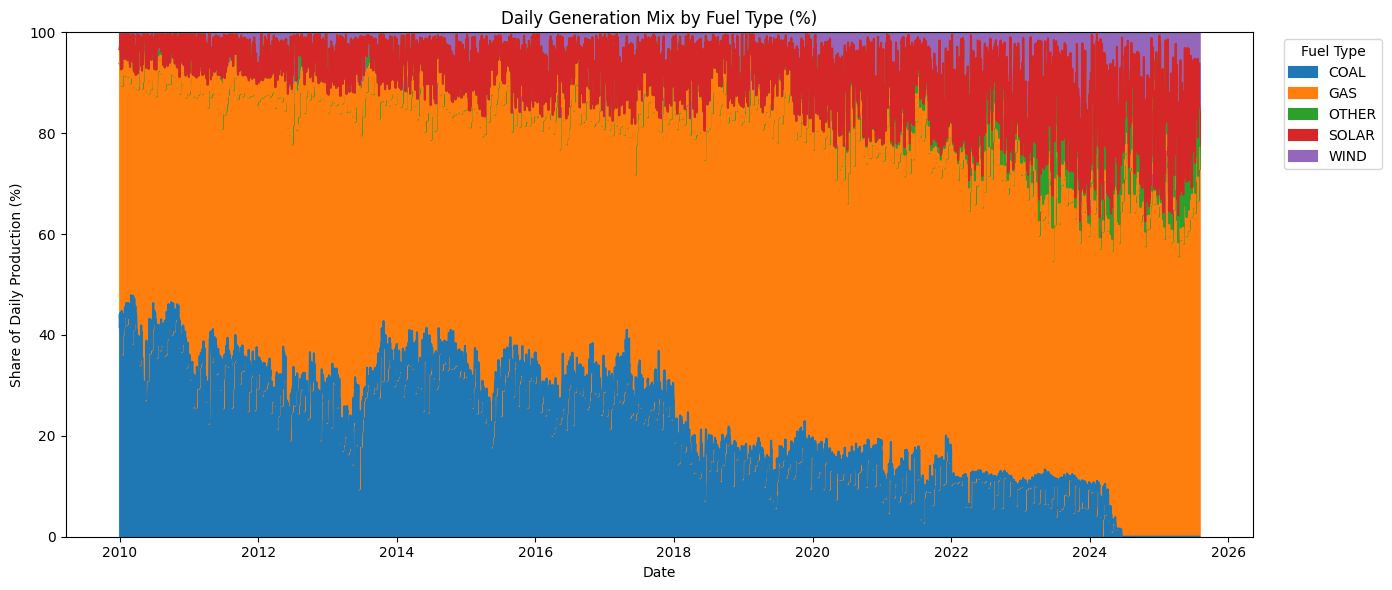

In [5]:
production = production_long.pivot_table(index='Date_Begin_Local', columns='FUEL_TYPE', values='production', aggfunc='sum')

production['total'] = production[['COAL', 'GAS', 'OTHER', 'SOLAR', 'WIND']].sum(axis=1)
production['date'] = production.index.date
production = production.groupby('date').sum()

production_daily_pct = production[['COAL', 'GAS', 'OTHER', 'SOLAR', 'WIND']].div(production['total'], axis=0) * 100

ax = production_daily_pct.plot(
    kind='area',
    figsize=(14, 6),
    linewidth=1.5
)
ax.set_ylim(0, 100)
ax.set_title("Daily Generation Mix by Fuel Type (%)")
ax.set_xlabel("Date")
ax.set_ylabel("Share of Daily Production (%)")
ax.legend(title="Fuel Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [6]:
production.head()

FUEL_TYPE,COAL,GAS,OTHER,SOLAR,WIND,total
date,,,,,,
2010-01-01,69586.185847,78671.315115,4548.928906,0.0,5287.441603,158093.871471
2010-01-02,65603.909880,82782.030684,4990.738097,0.0,4986.062202,158362.740863
2010-01-03,67810.463013,83741.592944,4878.522774,0.0,4083.971147,160514.549878
2010-01-04,71667.442600,89402.949168,5460.528388,0.0,62.821336,166593.741492
2010-01-05,73759.292540,86711.965722,5414.597644,0.0,404.561803,166290.417709


## Demand & Export Columns

In [7]:
demand = energy_data[['Date_Begin_Local'] + demand_columns].copy()
demand['net_export'] = energy_data[export_columns].sum(axis=1) - energy_data[import_columns].sum(axis=1)
demand['VWAP'] = (
    demand['ACTUAL_POOL_PRICE'] * demand['ACTUAL_AIL']
)
demand['date'] = demand['Date_Begin_Local'].dt.date
demand = demand.groupby('date').agg({
    'ACTUAL_AIL': 'sum',
    'net_export': 'sum',
    'VWAP': 'sum'
})
demand['VWAP'] = demand['VWAP'] / demand['ACTUAL_AIL']
demand.join(production.total).rename(columns={'total': 'total_production'}).head()
# demand.head()

,ACTUAL_AIL,net_export,VWAP,total_production
date,,,,
2010-01-01,200576,-1836.0,38.991603,158093.871471
2010-01-02,200023,-746.0,43.423681,158362.740863
2010-01-03,201227,104.0,37.128586,160514.549878
2010-01-04,211051,-3102.0,44.783139,166593.741492
2010-01-05,211964,-4154.0,42.454271,166290.417709


## Gas Price

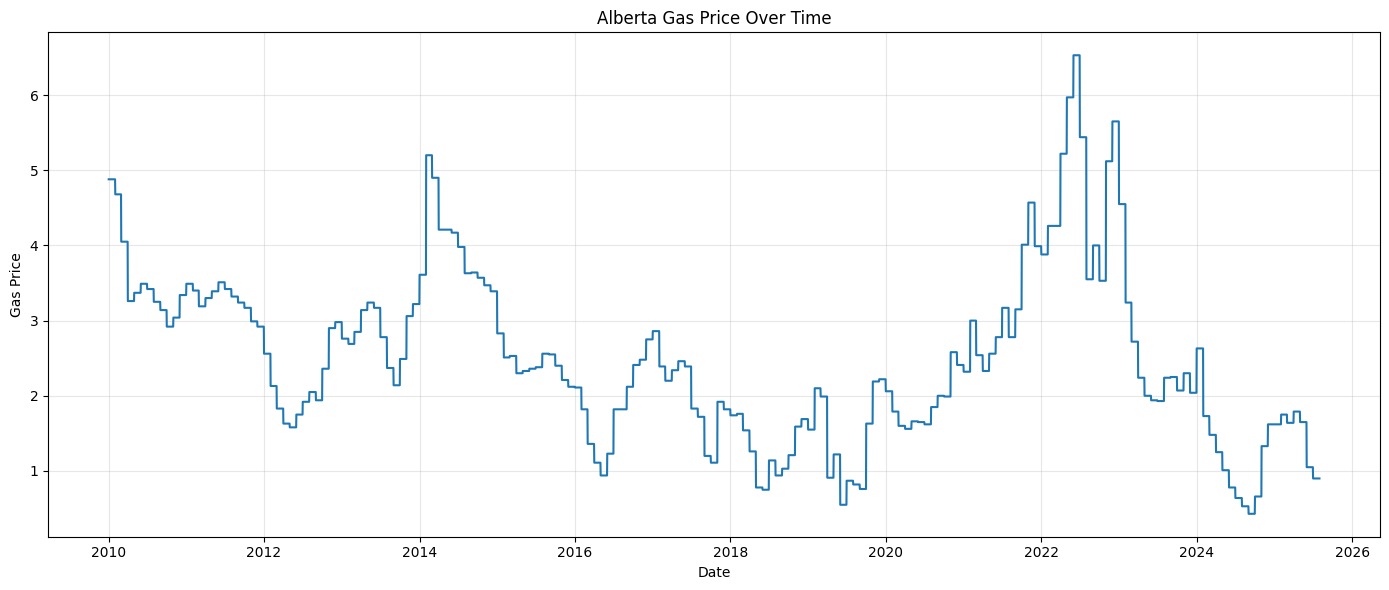

In [8]:
# Plot gas_price from energy_data
finance = energy_data[['Date_Begin_Local', 'gas_price']].copy()
finance['date'] = finance['Date_Begin_Local'].dt.date
finance = finance.groupby('date').agg({'gas_price': 'mean'})

plt.figure(figsize=(14, 6))
plt.plot(finance.index, finance['gas_price'], linewidth=1.5)
plt.xlabel('Date')
plt.ylabel('Gas Price')
plt.title('Alberta Gas Price Over Time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Fit total demand (AIL)

/tmp/ipykernel_1350489/3878556169.py:6: RuntimeWarning: invalid value encountered in log
  return A * np.log(x+C) + B


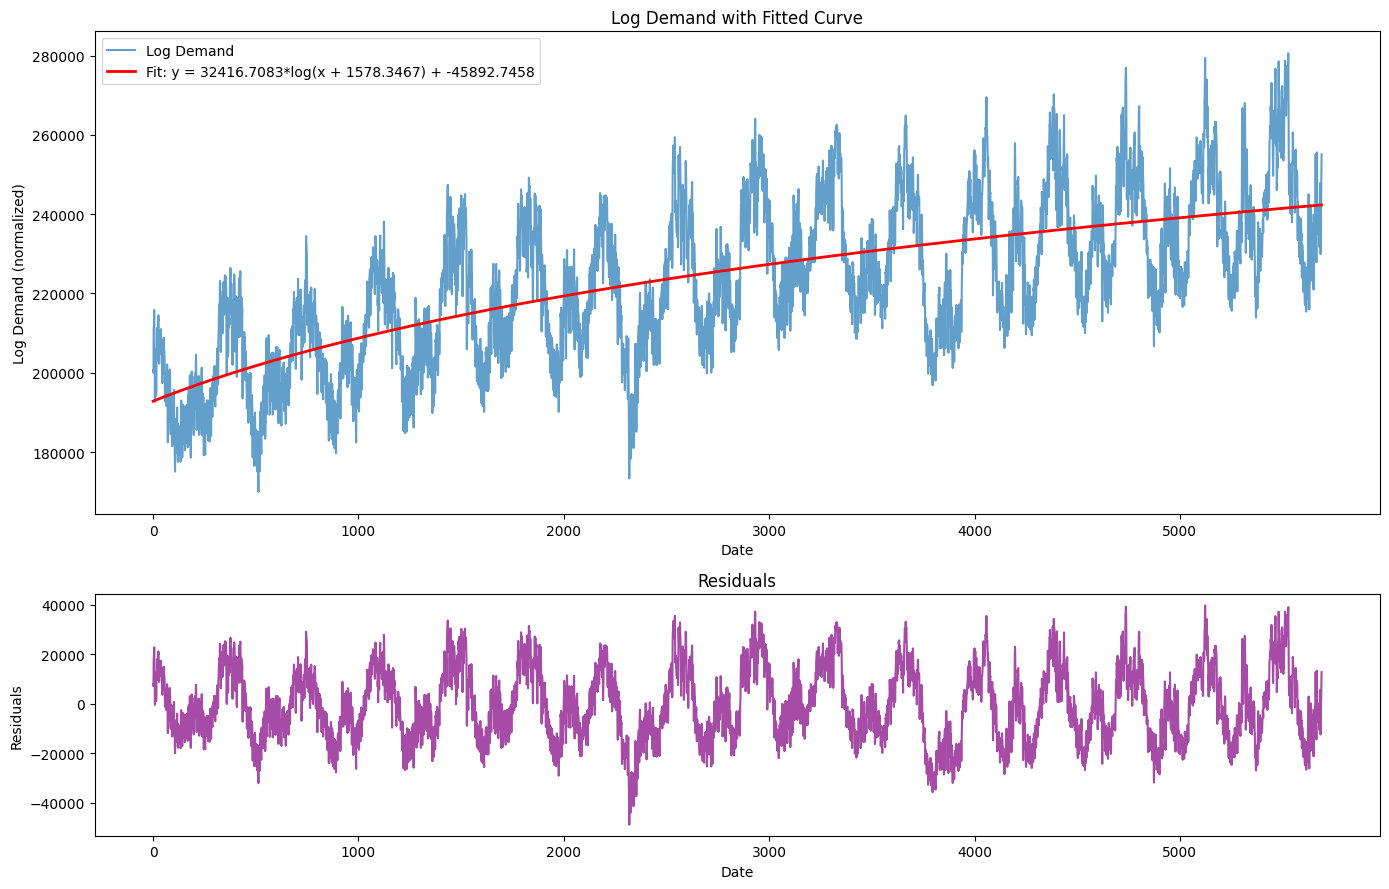

Fitted parameters: A = 32416.708324, B = -45892.745826, C = 1578.346682


In [9]:
from scipy.optimize import curve_fit
from scipy.stats import linregress

# Define the function y = A*log(x) + B
def log_func(x, A, B, C):
    return A * np.log(x+C) + B

# Prepare data: log_demand is a Series with date index
# We need x values (days since start) and y values
plot_data = demand['ACTUAL_AIL']
x_data = np.arange(len(plot_data))
y_data = plot_data

# Fit the curve
popt, pcov = curve_fit(log_func, x_data, y_data)
A, B, C = popt

# Plot
fig, ax = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={'height_ratios': [2, 1]})
ax[0].plot(x_data, y_data, label='Log Demand', linewidth=1.5, alpha=0.7)
ax[0].plot(x_data, log_func(x_data, A, B, C), label=f'Fit: y = {A:.4f}*log(x + {C:.4f}) + {B:.4f}', 
            linewidth=2, color='red')
ax[0].set_xlabel('Date')
ax[0].set_ylabel('Log Demand (normalized)')
ax[0].set_title('Log Demand with Fitted Curve')
ax[0].legend()


# Create residuals plot
demand_residuals = y_data - log_func(x_data, A, B, C)
ax[1].plot(x_data, demand_residuals, label='Residuals', linewidth=1.5, alpha=0.7, color='purple')
ax[1].set_ylabel('Residuals')
ax[1].set_xlabel('Date')
ax[1].set_title('Residuals')

plt.tight_layout()
plt.show()
print(f"Fitted parameters: A = {A:.6f}, B = {B:.6f}, C = {C:.6f}")

## Covariate Columns

In [10]:
data = pd.DataFrame()

# Response Variable Columns
data['VWAP'] = demand['VWAP']
data['VWAP_diff'] = demand['VWAP'].diff()
data['log_VWAP'] = np.log(demand['VWAP'])
data['log_diff_VWAP'] = data['log_VWAP'].diff()

# Generation Mix Features
data['renewable_penetration'] = ( production['SOLAR'] + production['WIND'] ) / demand['ACTUAL_AIL']
data['renewable_penetration_30d_avg'] = data['renewable_penetration'].rolling(window=30).mean()
data['gas_share'] = production['GAS'] / (demand['ACTUAL_AIL'] + demand['net_export'])
data['gas_share_30d_avg'] = data['gas_share'].rolling(window=30).mean()
data['coal_share'] = production['COAL'] / (demand['ACTUAL_AIL'] + demand['net_export'])
data['coal_share_30d_avg'] = data['coal_share'].rolling(window=30).mean()

# Export/Import Features
data['net_export_ratio'] = demand['net_export'] / demand['ACTUAL_AIL']

# Demand Features
data['relative_demand'] = (demand_residuals - demand_residuals.mean()) / demand_residuals.std()

# Financial Features
data['gas_price'] = finance['gas_price']

# Date Features
data.index = pd.to_datetime(demand.index)
data['month'] = data.index.month

data = data[1::].dropna()
data.to_csv('energy_data/processed_energy_data.csv', index=True)

data

,VWAP,VWAP_diff,log_VWAP,log_diff_VWAP,renewable_penetration,renewable_penetration_30d_avg,gas_share,gas_share_30d_avg,coal_share,coal_share_30d_avg,net_export_ratio,relative_demand,gas_price,month
date,,,,,,,,,,,,,,
2010-01-30,51.713121,-1.781552,3.945712,-0.033871,0.000066,0.021378,0.415303,0.414864,0.352153,0.340048,-0.045364,0.623323,4.88,1
2010-01-31,43.575659,-8.137462,3.774499,-0.171213,0.001979,0.020565,0.419810,0.415663,0.346360,0.339922,-0.036257,0.674477,4.88,1
2010-02-01,47.535795,3.960136,3.861483,0.086984,0.015438,0.020249,0.389890,0.414812,0.363331,0.341059,-0.043704,1.058036,4.68,2
2010-02-02,48.461122,0.925327,3.880762,0.019279,0.014570,0.020058,0.395700,0.414137,0.362373,0.341911,-0.032917,1.110177,4.68,2
2010-02-03,55.414706,6.953584,4.014845,0.134083,0.004086,0.020184,0.418882,0.413769,0.357610,0.342344,-0.028282,1.091096,4.68,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-27,11.816230,2.540132,2.469474,0.242033,0.090811,0.152067,0.598215,0.570890,0.000000,0.000000,0.060274,-0.790966,0.90,7
2025-07-28,15.366428,3.550199,2.732185,0.262711,0.084567,0.147346,0.617825,0.574287,0.000000,0.000000,0.059470,-0.159553,0.90,7
2025-07-29,48.304385,32.937957,3.877522,1.145337,0.114704,0.144807,0.591004,0.575921,0.000000,0.000000,0.041838,0.113769,0.90,7


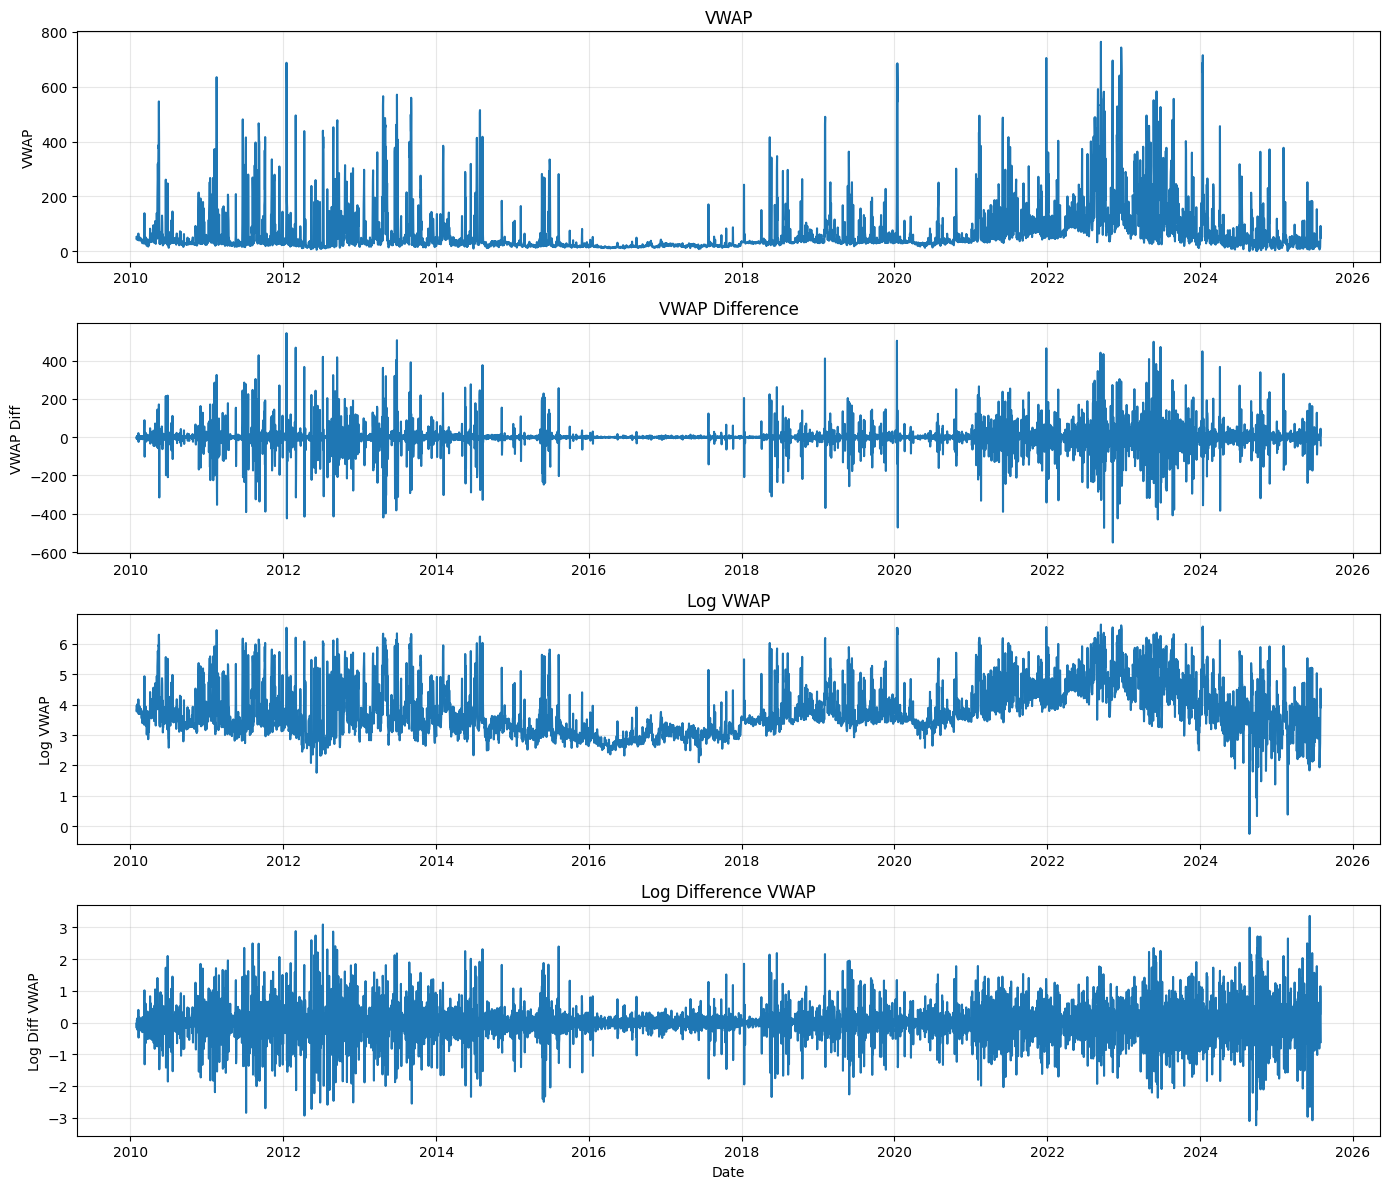

In [11]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

axes[0].plot(data.index, data['VWAP'], linewidth=1.5)
axes[0].set_ylabel('VWAP')
axes[0].set_title('VWAP')
axes[0].grid(True, alpha=0.3)

axes[1].plot(data.index, data['VWAP_diff'], linewidth=1.5)
axes[1].set_ylabel('VWAP Diff')
axes[1].set_title('VWAP Difference')
axes[1].grid(True, alpha=0.3)

axes[2].plot(data.index, data['log_VWAP'], linewidth=1.5)
axes[2].set_ylabel('Log VWAP')
axes[2].set_title('Log VWAP')
axes[2].grid(True, alpha=0.3)

axes[3].plot(data.index, data['log_diff_VWAP'], linewidth=1.5)
axes[3].set_ylabel('Log Diff VWAP')
axes[3].set_xlabel('Date')
axes[3].set_title('Log Difference VWAP')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


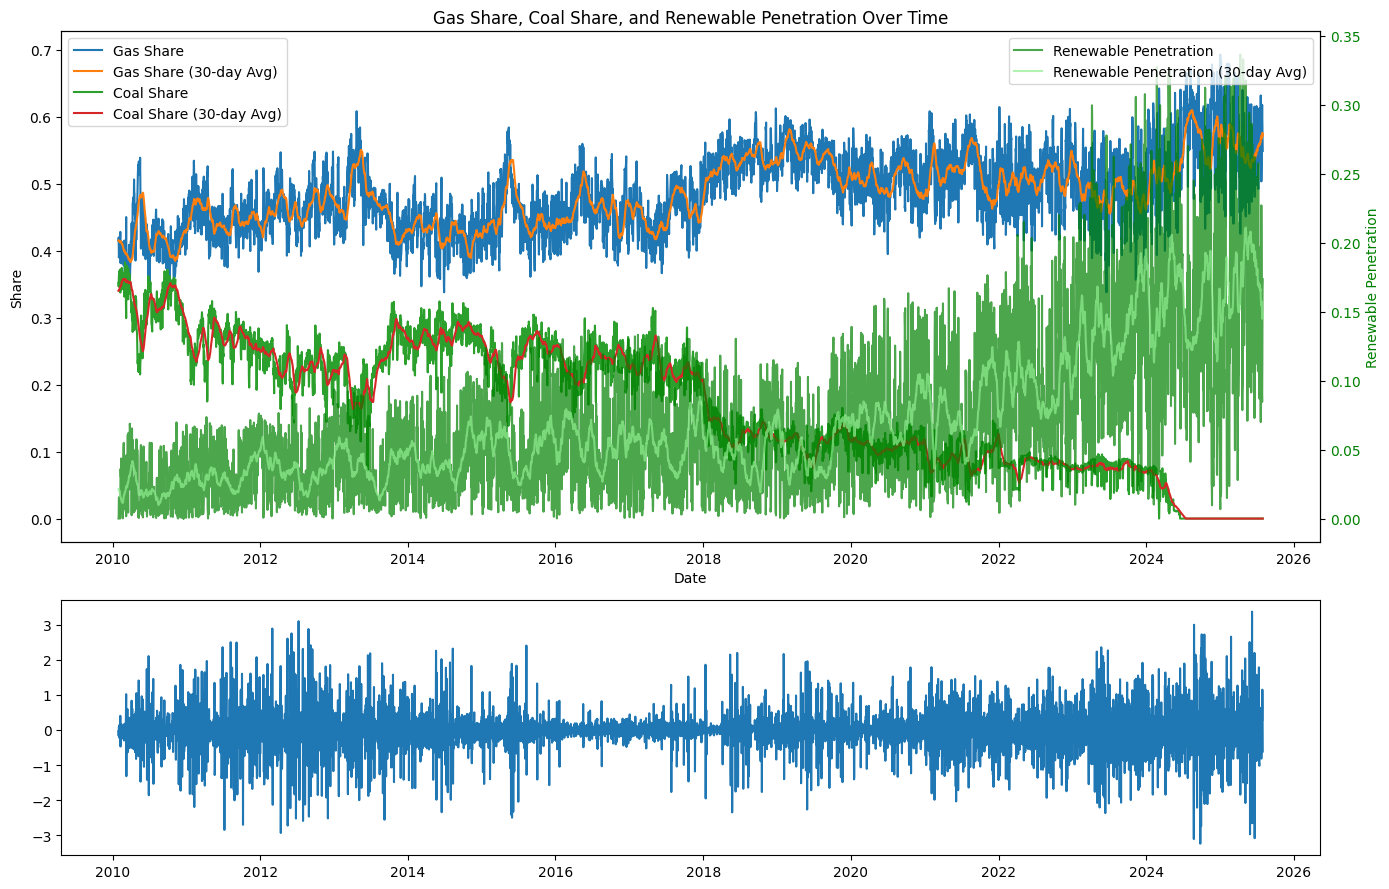

In [12]:
fig, ax = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={'height_ratios': [2, 1]})

# Plot gas_share and coal_share on left axis
ax1 = ax[0]
ax1.plot(data.index, data['gas_share'], label='Gas Share', linewidth=1.5)
ax1.plot(data.index, data['gas_share_30d_avg'], label='Gas Share (30-day Avg)', linewidth=1.5)
ax1.plot(data.index, data['coal_share'], label='Coal Share', linewidth=1.5)
ax1.plot(data.index, data['coal_share_30d_avg'], label='Coal Share (30-day Avg)', linewidth=1.5)
ax1.set_xlabel('Date')
ax1.set_ylabel('Share', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.legend(loc='upper left')

# Create right axis for renewable_penetration
ax2 = ax1.twinx()
ax2.plot(data.index, data['renewable_penetration'], label='Renewable Penetration', 
         color='green', alpha=0.7, linewidth=1.5)
ax2.plot(data.index, data['renewable_penetration_30d_avg'], label='Renewable Penetration (30-day Avg)', 
         color='lightgreen', alpha=0.7, linewidth=1.5)
ax2.set_ylabel('Renewable Penetration', color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.legend(loc='upper right')

ax[1].plot(data.index, data['log_diff_VWAP'], linewidth=1.5)

plt.title('Gas Share, Coal Share, and Renewable Penetration Over Time')
plt.tight_layout()
plt.show()

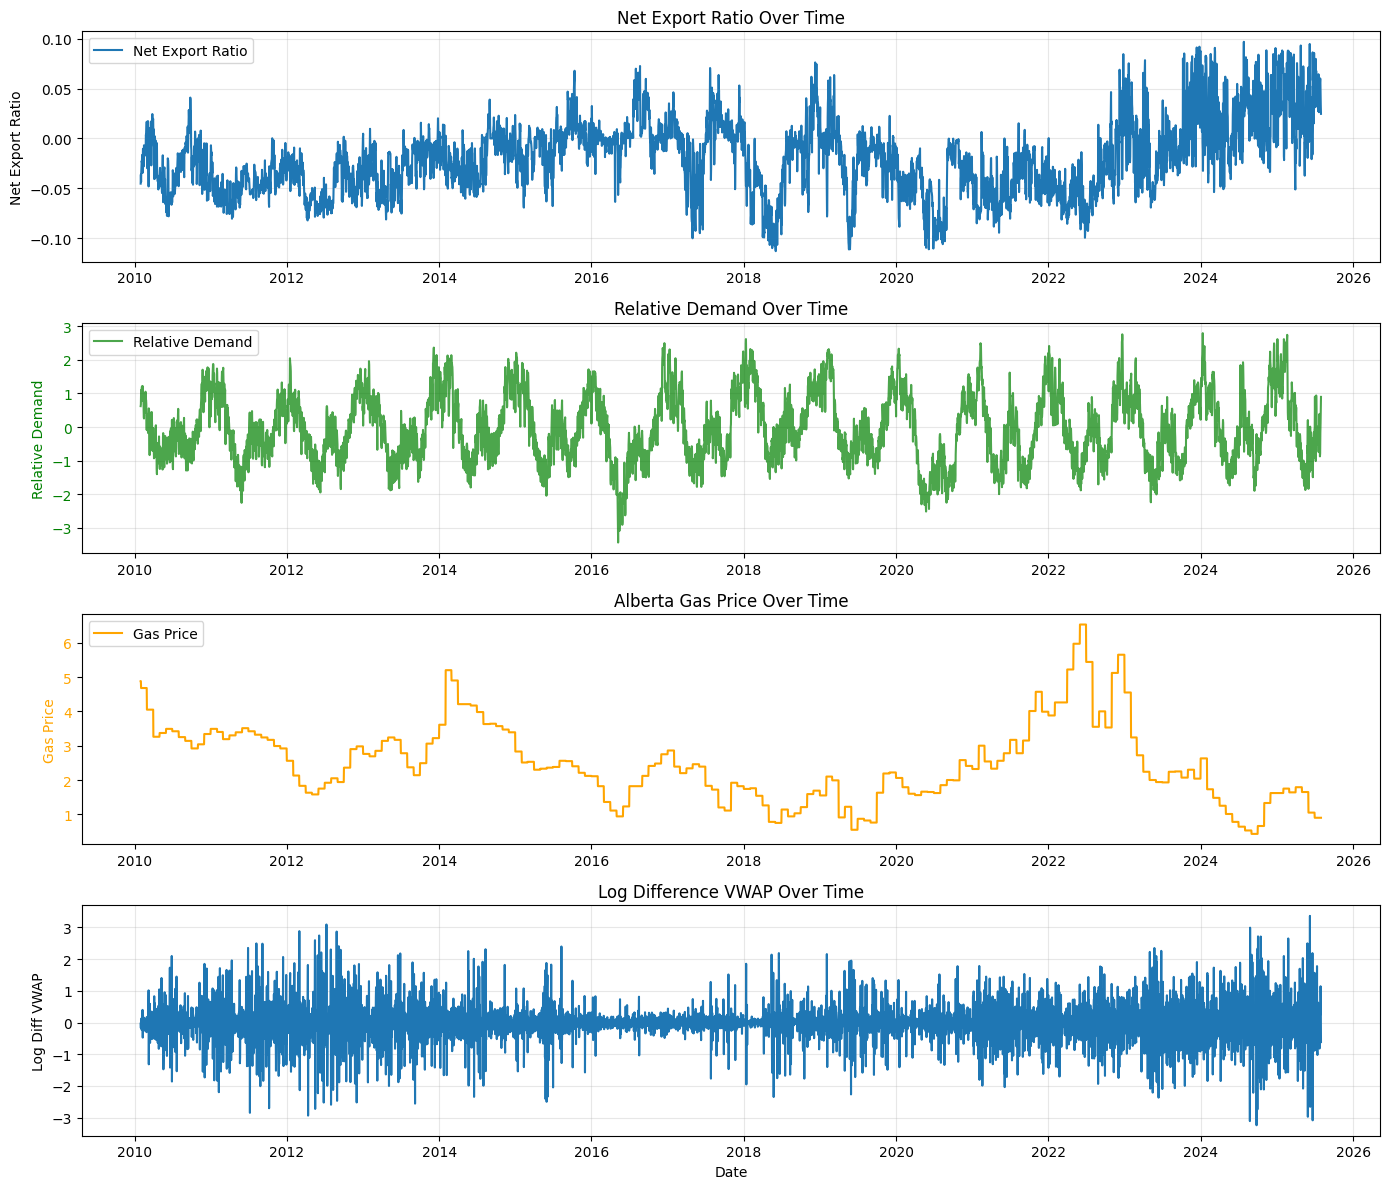

In [13]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

# Row 1: Net Export Ratio
axes[0].plot(data.index, data['net_export_ratio'], label='Net Export Ratio', linewidth=1.5)
axes[0].set_ylabel('Net Export Ratio', color='black')
axes[0].tick_params(axis='y', labelcolor='black')
axes[0].legend(loc='upper left')
axes[0].set_title('Net Export Ratio Over Time')
axes[0].grid(True, alpha=0.3)

# Row 2: Relative Demand
axes[1].plot(data.index, data['relative_demand'], label='Relative Demand', 
             color='green', alpha=0.7, linewidth=1.5)
axes[1].set_ylabel('Relative Demand', color='green')
axes[1].tick_params(axis='y', labelcolor='green')
axes[1].legend(loc='upper left')
axes[1].set_title('Relative Demand Over Time')
axes[1].grid(True, alpha=0.3)

# Row 3: Gas Price
axes[2].plot(data.index, data['gas_price'], label='Gas Price', color='orange', linewidth=1.5)
axes[2].set_ylabel('Gas Price', color='orange')
axes[2].tick_params(axis='y', labelcolor='orange')
axes[2].legend(loc='upper left')
axes[2].set_title('Alberta Gas Price Over Time')

# Row 4: Log Diff VWAP
axes[3].plot(data.index, data['log_diff_VWAP'], linewidth=1.5)
axes[3].set_ylabel('Log Diff VWAP')
axes[3].set_xlabel('Date')
axes[3].set_title('Log Difference VWAP Over Time')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()